# Installation and configuration of IBL packages

In [1]:
!pip install --quiet ONE-api
!pip install --quiet ibllib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.0/211

In [1]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

/opt/anaconda3/lib/python3.8/site-packages/one/api.py:1644: UserWarning: Newer cache tables require ONE version 2.10 or greater
  warnings.warn(f'Newer cache tables require ONE version {min_version} or greater')


In [25]:
# Suppress some future warnings
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Change the load method depending on python version
from one.remote.aws import s3_download_file, get_s3_public
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
python_ver = sys.version_info

if python_ver >= (3, 10):
    from one.alf.path import add_uuid_string
else:
    from one.alf.files import add_uuid_string

s3, bucket = get_s3_public()

def load_aggregate(subject, dataset):
    if sys.version_info >= (3, 10):
        return one.load_aggregate('subjects', subject, dataset)
    else:
        files = one.list_aggregates('subjects', subject, dataset=dataset)
        files = files.iloc[0]
        src_path = str(add_uuid_string(files['rel_path'], files.name))
        dst_path = one.cache_dir.joinpath(files['rel_path'])
        local_file = s3_download_file(src_path, dst_path, s3=s3, bucket_name=bucket)
        return pd.read_parquet(local_file)

# Finding subjects with training data

In [3]:
import numpy as np

# Find all aggregate training datasets from IBL behaviour paper
datasets = one.alyx.rest('datasets', 'list', tag='2021_Q1_IBL_et_al_Behaviour', name='_ibl_subjectTrials.table.pqt')

# Find the subject name from the info stored in the relative path
subjects = np.unique([d['file_records'][0]['relative_path'].split('/')[2] for d in datasets])

# Loading trials data for a single subject

In [85]:
# Load in the subjectTrials table and sessionTrials table for the first subject
subject = subjects[0]
subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')
session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

# Add in lab, task_protocol, subject name information from the sessions table
if 'task_protocol' in subject_trials:
    subject_trials = subject_trials.drop('task_protocol', axis=1)
subject_trials = subject_trials.set_index('session').join(session_trials.drop('date', axis=1))

No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent


The `subject_trials` table contains all the trials data for each training session collected in the subject. See [here](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.ls81qq9ihg4x) for more information about this dataset.

We can find the number of sessions collected, or the number of times the subject was run under a specific task protocol

In [108]:
len(subjects)

140

In [ ]:
# Find the number of sessions for this subject
n_sessions = subject_trials.index.unique().size
print(f'Subject {subject} has {n_sessions} sessions')

# Find the number of times a task protocol was run
n_protocols = subject_trials[~subject_trials.index.duplicated()].task_protocol.value_counts()
print(n_protocols)

Subject CSHL045 has 76 sessions
task_protocol
_iblrig_tasks_biasedChoiceWorld6.3.1      17
_iblrig_tasks_trainingChoiceWorld6.1.3    14
_iblrig_tasks_trainingChoiceWorld6.2.5    12
_iblrig_tasks_trainingChoiceWorld6.3.1    11
_iblrig_tasks_biasedChoiceWorld6.2.5       6
_iblrig_tasks_ephysChoiceWorld6.2.5        3
_iblrig_tasks_trainingChoiceWorld6.2.4     3
_iblrig_tasks_trainingChoiceWorld6.0.6     3
_iblrig_tasks_trainingChoiceWorld6.2.1     2
_iblrig_tasks_ephysChoiceWorld6.4.0        2
_iblrig_tasks_trainingChoiceWorld6.2.0     1
_iblrig_tasks_trainingChoiceWorld6.1.1     1
_iblrig_tasks_trainingChoiceWorld6.1.2     1
Name: count, dtype: int64


We can get the trials data for an individual session of choice, here a the first session using the biasedChoiceWorld protocol

In [58]:
# Get the trials data for a single session
# Find a session run under biasedChoiceWorld
sess_list = subject_trials[subject_trials['task_protocol'].str.contains('biasedChoiceWorld')].index.unique()
trials = subject_trials[subject_trials.index.isin(sess_list)]

In [43]:
trials.columns

Index(['intervals_0', 'intervals_1', 'goCue_times', 'response_times', 'choice',
       'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times',
       'feedbackType', 'rewardVolume', 'probabilityLeft',
       'firstMovement_times', 'goCueTrigger_times', 'stimOnTrigger_times',
       'stimOffTrigger_times', 'stimFreezeTrigger_times', 'stimOff_times',
       'stimFreeze_times', 'phase', 'position', 'quiescence',
       'protocol_number', 'session_start_time', 'lab', 'subject', 'number',
       'task_protocol', 'projects'],
      dtype='object')

In [126]:
trials.head()
trials[trials['probabilityLeft'] == 0.5].head()

,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,...,session_start_time,training_status,lab,subject,number,task_protocol,projects,performance_easy,training_day,session_number
session,,,,,,,,,,,,,,,,,,,,,
a4f7079b-d157-4de9-ba80-de9a98f35c8b,0.0000,10.582602,5.7094,7.9825,1.0,NaN,NaN,0.0625,8.0115,-1.0,...,2020-01-22 09:17:29.099405,trained 1b,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.945736,48.0,NaN
a4f7079b-d157-4de9-ba80-de9a98f35c8b,11.0663,14.771902,11.7101,12.2011,1.0,11.6799,NaN,0.0625,12.2314,-1.0,...,2020-01-22 09:17:29.099405,trained 1b,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.945736,48.0,NaN
a4f7079b-d157-4de9-ba80-de9a98f35c8b,15.2211,20.156802,18.0630,18.5762,-1.0,18.0323,NaN,0.2500,18.5763,1.0,...,2020-01-22 09:17:29.099405,trained 1b,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.945736,48.0,NaN
a4f7079b-d157-4de9-ba80-de9a98f35c8b,20.5800,24.817402,21.5136,22.2572,1.0,21.4835,NaN,0.0625,22.2869,-1.0,...,2020-01-22 09:17:29.099405,trained 1b,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.945736,48.0,NaN
a4f7079b-d157-4de9-ba80-de9a98f35c8b,25.2225,28.892902,25.7895,26.3258,1.0,25.7587,NaN,0.0000,26.3548,-1.0,...,2020-01-22 09:17:29.099405,trained 1b,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.945736,48.0,NaN


In [59]:
trials['probabilityLeft'].value_counts()

probabilityLeft
0.8    10305
0.2     9935
0.5     2070
Name: count, dtype: int64

In [60]:
# Create a boolean mask to identify where the probability of a left stimulus is NOT 0.5
biased_mask = trials["probabilityLeft"] != 0.5

# Extract all biased trials into a new DataFrame
biased_trials = trials[biased_mask].copy()

print(len(biased_trials), "biased trials found out of", len(trials), "total trials.")

20240 biased trials found out of 22310 total trials.


In [61]:
# Add a new column to the biased_trials DataFrame to indicate whether the trial had an uncommon stimulus
biased_trials['uncommon_stimulus'] = biased_trials.apply(lambda row: 0 if (row['probabilityLeft'] > 0.5 and row['contrastLeft'] > 0) or (row['probabilityLeft'] < 0.5 and row['contrastRight'] > 0) else 1, axis=1)
biased_trials['uncommon_stimulus'].value_counts()

uncommon_stimulus
0    12961
1     7279
Name: count, dtype: int64

In [62]:
# Combine columns; if contrastLeft is NaN/0, it takes the value from contrastRight
biased_trials["contrast"] = biased_trials["contrastLeft"].fillna(biased_trials["contrastRight"])
biased_trials["contrast"].value_counts()

contrast
0.1250    4116
0.0000    4061
0.0625    4030
0.2500    4029
1.0000    4004
Name: count, dtype: int64

In [63]:
# Calculate reaction time for biased trials
biased_trials['reaction_time'] = biased_trials['response_times'] - biased_trials['goCue_times']
biased_trials['reaction_time'].describe()

count    20240.000000
mean         1.029949
std          2.737585
min         -0.506200
25%          0.275500
50%          0.378300
75%          0.729125
max         60.000100
Name: reaction_time, dtype: float64

In [64]:
# Insepct the trials with negative reaction times
idx = biased_trials['reaction_time'] < 0
biased_trials[idx].head()

,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,...,session_start_time,lab,subject,number,task_protocol,projects,training_status,uncommon_stimulus,contrast,reaction_time
session,,,,,,,,,,,,,,,,,,,,,
1a559aac-f6dd-47c8-bccb-53b4ae5af509,4944.885598,4947.546900,4946.485098,4945.978898,1.0,4945.554398,0.25,NaN,4945.978998,1.0,...,2020-01-23 09:23:45.493773,churchlandlab,CSHL045,1,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,trained 1b,0,0.25,-0.5062
f8db8924-0e05-4d35-aed4-739021e36c91,1304.936700,1308.476301,1305.921700,1305.919500,-1.0,1305.609400,0.00,NaN,1305.986700,-1.0,...,2020-01-24 09:29:23.295873,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,trained 1b,1,0.00,-0.0022


In [65]:
# Remove trials with negative reaction times
biased_trials = biased_trials[biased_trials['reaction_time'] >= 0]

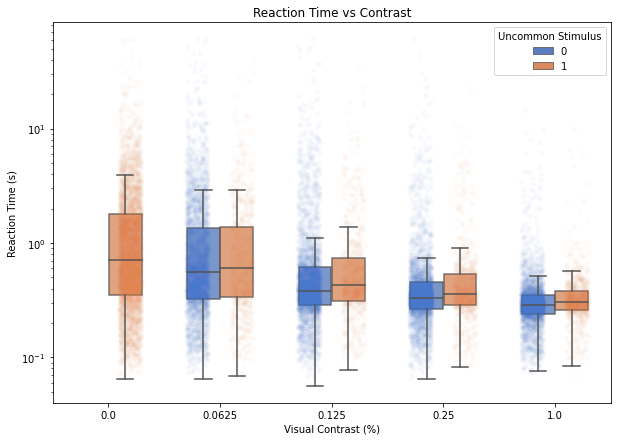

In [80]:
# Create a single figure and axis
fig, ax = plt.subplots(figsize=(10, 7))

# 1. Plot the jittered scatter points first
sns.stripplot(
    data=biased_trials,
    x="contrast",
    y="reaction_time",
    hue="uncommon_stimulus",
    dodge=True,  # Separates categories horizontally
    alpha=0.03,  # Makes dots translucent to show density
    jitter=0.2,  # Spreads points laterally
    palette="muted",
    ax=ax,
    zorder=1
)

# 2. Superimpose the Boxplot directly on top
sns.boxplot(
    data=biased_trials,
    x="contrast",
    y="reaction_time",
    hue="uncommon_stimulus",
    dodge=True,  # Must match the stripplot's dodge
    width=0.6,  # Slightly narrower boxes
    fliersize=0,  # Prevents drawing outliers twice
    palette="muted",
    boxprops=dict(alpha=0.8),  # Translucent boxes so points remain visible
    ax=ax,
    zorder=2
)

# 3. Clean up the duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Uncommon Stimulus")

# Formatting the axis
ax.set_title("Reaction Time vs Contrast")
ax.set_xlabel("Visual Contrast (%)")
ax.set_ylabel("Reaction Time (s)")
ax.set_yscale("log")  # Using log scale to handle right-skewed reaction times

plt.show()

In [81]:
# Group by contrast and uncommon_stimulus, then calculate the proportion of correct trials
accuracy_data = (
    biased_trials.groupby(["contrast", "uncommon_stimulus"])["feedbackType"]
    .apply(lambda x: (x == 1).mean())
    .reset_index(name="accuracy")
)

# Display the resulting DataFrame
print(accuracy_data)

   contrast  uncommon_stimulus  accuracy
0    0.0000                  1  0.628079
1    0.0625                  0  0.797437
2    0.0625                  1  0.418773
3    0.1250                  0  0.909091
4    0.1250                  1  0.670171
5    0.2500                  0  0.963272
6    0.2500                  1  0.829949
7    1.0000                  0  0.985786
8    1.0000                  1  0.916468


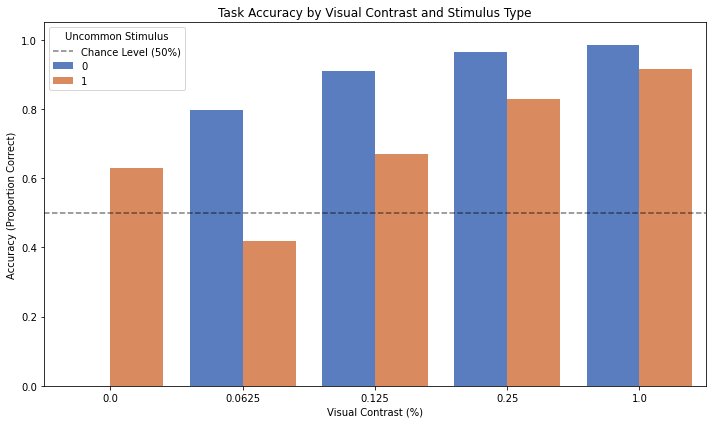

In [82]:
# Initialize the plot layout
plt.figure(figsize=(10, 6))

# Create the barplot
sns.barplot(
    data=accuracy_data,
    x="contrast",
    y="accuracy",
    hue="uncommon_stimulus",
    palette="muted",
)

# Add a baseline chance level line at 50% accuracy
plt.axhline(
    0.5, color="black", linestyle="--", alpha=0.5, label="Chance Level (50%)"
)

# Formatting adjustments
plt.title("Task Accuracy by Visual Contrast and Stimulus Type")
plt.xlabel("Visual Contrast (%)")
plt.ylabel("Accuracy (Proportion Correct)")
plt.ylim(0, 1.05)  # Constrain Y-axis from 0% to just past 100%

# Re-draw the legend to cleanly combine the bars and the chance line
plt.legend(title="Uncommon Stimulus")

plt.tight_layout()
plt.show()

In [83]:
# Inspect the distribution of uncommon_stimulus for trials with 0 contrast
biased_trials[biased_trials['contrast'] == 0]['uncommon_stimulus'].value_counts()

uncommon_stimulus
1    4060
Name: count, dtype: int64

Using this data we can plot the psychometric curve and compute some performance metrics, for example the number of trials in the session or the performance of the mouse on easy trials (50% and 100% contrast)

## Combining training criteria

Another [dataset](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.18vu2zskyq0r) is available that contains information about the session at which the subject reached certain training criteria in the IBL training pipeline. More information can be found about the training pipeline in the study [A standardized and reproducible method to measure decision-making in mice](https://doi.org/10.1101/2020.01.17.909838).

We can download this dataset in the following way

In [49]:
subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL045/#2024-08-21#/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.27k/3.27k [00:00<00:00, 4.85kB/s]


We can combine this with our subject trials table to see how the subject progressed

In [86]:
subject_trials = (subject_trials
          .join(subject_training.set_index('session'))
          .sort_values(by=['session_start_time', 'intervals_0']))
subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

In [51]:
subject_trials['training_status'].value_counts()

training_status
in training        24750
trained 1b         11225
ready4ephysrig      8743
ready4recording     7363
untrainable         5849
ready4delay         1875
Name: count, dtype: int64

In [87]:
trials['training_status'].value_counts()

training_status
ready4ephysrig     8743
trained 1b         8279
ready4recording    3413
ready4delay        1875
Name: count, dtype: int64

Our subject trials table now has a new column that indicates the training criteria of the mouse at each session. We can use this information to make a plot of how the performance of the mouse improved across training days.

We will need to compute the performance per session and add this column to our dataframe and also add in a column for training day.

In [90]:
from brainbox.behavior.training import plot_psychometric, compute_n_trials, compute_performance_easy, compute_performance
sessions = subject_trials.index.unique()
for n_sess, sess in enumerate(sessions):
  trials = subject_trials[subject_trials.index == sess]
  perf_easy = compute_performance_easy(trials)
  subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
  subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess

Note since we already ordered by session_start_time above our table was already sorted. Here we have simply assigned each training session to a training day but there are some cases where multiple training sessions were run on the same day so this may be something you want to account for in your analysis.

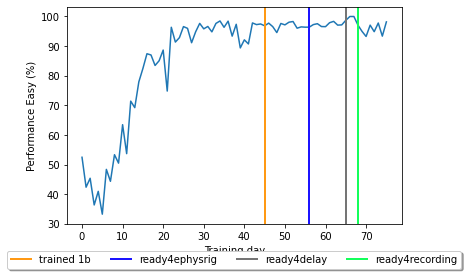

In [100]:
import matplotlib.pyplot as plt
from ibllib.pipes.training_status import TRAINING_STATUS
fig, ax = plt.subplots(1, 1)
# Extract raw values using .values to bypass the multi-dimensional index issue
x_data = subject_trials['training_day'].values
y_data = subject_trials['performance_easy'].values * 100

ax.plot(x_data, y_data)
ax.set_xlabel("Training day")
ax.set_ylabel("Performance Easy (%)")
status = subject_trials.drop_duplicates(subset='training_status', keep='first')
for _, st in status.iterrows():
    # if st['training_status'] in ['untrainable', 'unbiasable']:
    #     continue
    if TRAINING_STATUS[st['training_status']][0] <= 0:
        continue
    ax.axvline(st['training_day'], linewidth=2,
               color=np.array(TRAINING_STATUS[st['training_status']][1]).flatten() / 255, label=st['training_status'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
                   fancybox=True, shadow=True, ncol=5)

# Combining data across multiple subjects

We can loop over all the subjects available to get a large dataframe that contains the data for all the subjects. Here is an example of how this can be done


In [101]:
import pandas as pd

all_trials = []

# Download two tables, subject trials table and subject training table and combine
for i, subject in enumerate(subjects):
  if np.mod(i, 50) == 0:
    print(f'{i}/{len(subjects)}')

  # Load trials table for subject
  subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')

  # Load sessions table for subject
  session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

  # Load training status for subject
  subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

  # Combine the two tables
  subject_trials = (subject_trials
            .set_index('session')
            .join(subject_training.set_index('session'))
            .sort_values(by=['session_start_time', 'intervals_0']))
  subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

  # Join sessions table for number, task_protocol, etc.
  if 'task_protocol' in subject_trials:
      subject_trials = subject_trials.drop('task_protocol', axis=1)
  subject_trials = subject_trials.join(session_trials.drop('date', axis=1))

  # Sort the trials by session start time and trial number
  subject_trials = subject_trials.sort_values(by=['session_start_time', 'intervals_0'])


  # add in extra columns for performance easy and training day
  sessions = subject_trials.index.unique()
  for n_sess, sess in enumerate(sessions):
    trials = subject_trials[subject_trials.index == sess]
    perf_easy = compute_performance_easy(trials)
    subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
    subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess


  all_trials.append(subject_trials)

all_trials = pd.concat(all_trials)

No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent


0/140


No default revision for dataset aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectTrials.table.pqt; using most recent
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/#2024-08-21#/_ibl_subjectTrials.table.pqt: 100%|██████████| 11.1M/11.1M [00:07<00:00, 1.52MB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectSessions.table.pqt: 100%|██████████| 10.2k/10.2k [00:00<00:00, 18.1kB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.26k/3.26k [00:00<00:00, 5.98kB/s]
No default revision for dataset aggregates/Subjects/churchlandlab/CSHL047/#2024-08-21#/_ibl_subjectTrials.table.pqt; using most recent
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/churchlandlab/CSHL047/#2024-08-21#/_ibl_subjectTrials.table.pqt: 10

50/140


/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/angelakilab/IBL-T3/#2024-04-10#/_ibl_subjectTrials.table.pqt: 100%|██████████| 8.34M/8.34M [00:03<00:00, 2.38MB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/angelakilab/IBL-T3/_ibl_subjectSessions.table.pqt: 100%|██████████| 9.75k/9.75k [00:00<00:00, 17.1kB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/angelakilab/IBL-T3/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.12k/3.12k [00:00<00:00, 4.88kB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/angelakilab/IBL-T4/#2024-04-10#/_ibl_subjectTrials.table.pqt: 100%|██████████| 7.39M/7.39M [00:04<00:00, 1.82MB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/angelakilab/IBL-T4/_ibl_subjectSessions.table.pqt: 100%|██████████| 9.82k/9.82k [00:00<00:00, 14.6kB/s]
/Users/ellenying/Downloads/O

100/140


/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectTrials.table.pqt: 100%|██████████| 1.57M/1.57M [00:00<00:00, 2.07MB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectSessions.table.pqt: 100%|██████████| 6.52k/6.52k [00:00<00:00, 11.8kB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1092/_ibl_subjectTraining.table.pqt: 100%|██████████| 3.08k/3.08k [00:00<00:00, 4.81kB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1093/_ibl_subjectTrials.table.pqt: 100%|██████████| 1.28M/1.28M [00:00<00:00, 1.72MB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainlab.org/aggregates/Subjects/mainenlab/ZM_1093/_ibl_subjectSessions.table.pqt: 100%|██████████| 6.33k/6.33k [00:00<00:00, 10.8kB/s]
/Users/ellenying/Downloads/ONE/openalyx.internationalbrainl

In [ ]:
# Save the combined trials data to a CSV file
# path = 'all_trials.csv'
# all_trials.to_csv(path, index=False)

In [113]:
import re
# Helper function to filter the dataset for sessions that utilize a 'biasedChoiceWorld' task protocol
def get_biased_choice_world_sessions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filters the dataset to extract all trials for sessions that utilize 
    a 'biasedChoiceWorld' task protocol.
    
    Parameters:
    df (pd.DataFrame): Input dataframe where the index contains unique session identifiers.
    
    Returns:
    pd.DataFrame: A filtered dataframe containing all trials for the selected sessions.
    """
    # 1. Track total unique sessions before filtering
    total_sessions = df.index.nunique()
    
    # 2. Isolate unique session IDs that match the target protocol
    # na=False prevents errors if any rows have empty/NaN task protocols
    biased_mask = df['task_protocol'].str.contains('biasedChoiceWorld', na=False)
    selected_sessions_list = df[biased_mask].index.unique()
    
    # 3. Extract all trials belonging to those unique sessions
    filtered_df = df[df.index.isin(selected_sessions_list)]
    num_selected_sessions = len(selected_sessions_list)
    
    # 4. Calculate how many unique SESSIONS (not trials) belong to each protocol variant
    # We drop duplicate indices to ensure we count 1 per session
    index_col_name = df.index.name if df.index.name is not None else 'index'
    session_metadata = (
        filtered_df[['task_protocol']]
        .reset_index()
        .drop_duplicates(subset=[index_col_name])
    )

    # 5. Clean protocol names by stripping trailing version numbers (e.g., 6.2.0, 4.1.2)
    # This regex searches for numbers separated by dots at the end of the text string
    session_metadata["clean_protocol"] = session_metadata[
        "task_protocol"
    ].apply(lambda x: re.sub(r"\d+\.\d+\.\d+$", "", str(x)).rstrip("_"))

    # Count the stripped, version-insensitive protocols
    protocol_counts = session_metadata["clean_protocol"].value_counts()

    # --- Clean Summary Output ---
    print("## Session Filtering Summary")
    print("---")
    print(f"* **Total Unique Sessions in Dataset:** {total_sessions}")
    print(f"* **Selected 'biasedChoiceWorld' Sessions:** {num_selected_sessions}")
    print("\n### Protocol Breakdown (Version-Insensitive Counts):")

    for protocol_name, session_count in protocol_counts.items():
        print(f"  * `{protocol_name}`: **{session_count}** session(s)")
    print("---")

    return filtered_df

In [130]:
all_biased_sessions = get_biased_choice_world_sessions(all_trials)

## Session Filtering Summary
---
* **Total Unique Sessions in Dataset:** 8135
* **Selected 'biasedChoiceWorld' Sessions:** 4013

### Protocol Breakdown (Version-Insensitive Counts):
  * `_iblrig_tasks_biasedChoiceWorld`: **4010** session(s)
  * `_bandit_shaping_90_10_biasedChoiceWorld`: **1** session(s)
  * `_bandit_shaping_100_0_biasedChoiceWorld`: **1** session(s)
  * `_bandit_shaping_biasedChoiceWorld`: **1** session(s)
---


In [ ]:
# Helper function to filter out trials where the probability of a left stimulus is exactly 0.5
def remove_unbiased_trials(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filters out trials where the probability of a left stimulus is exactly 0.5,
    leaving only biased blocks, and prints processing metrics.
    
    Parameters:
    df (pd.DataFrame): The original trials dataframe.
    
    Returns:
    pd.DataFrame: A new dataframe containing only biased trials.
    """
    # 1. Calculate baseline row metrics
    total_rows = len(df)
    
    if total_rows == 0:
        print("## Trial Filtering Summary")
        print("---")
        print("* **Warning:** The input DataFrame is empty.")
        return df

    # 2. Apply your mask to isolate biased trials
    biased_mask = df["probabilityLeft"] != 0.5
    filtered_df = df[biased_mask].copy()
    
    # 3. Calculate removal statistics
    remaining_rows = len(filtered_df)
    removed_rows = total_rows - remaining_rows
    pct_removed = (removed_rows / total_rows) * 100

    # --- Clean Summary Output ---
    print("## Trial Filtering Summary")
    print("---")
    print(f"* **Total Trials (Original):** {total_rows:,}")
    print(f"* **Trials Removed (Unbiased 0.5 Blocks):** {removed_rows:,}")
    print(f"* **Percentage of Rows Removed:** {pct_removed:.2f}%")
    print(f"* **Biased Trials Retained:** {remaining_rows:,}")
    print("---")
    
    return filtered_df

In [131]:
all_biased_sessions = remove_unbiased_trials(all_biased_sessions)

## Trial Filtering Summary
---
* **Total Trials (Original):** 2,975,551
* **Trials Removed (Unbiased 0.5 Blocks):** 353,525
* **Percentage of Rows Removed:** 11.88%
* **Biased Trials Retained:** 2,622,026
---


In [129]:
def preprocess_biased_trials(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocesses biased trial data by calculating target stimulus traits,

    combining contrast vectors, computing reaction times, and filtering out
    unphysical (negative) timings.

    Parameters:
    df (pd.DataFrame): The filtered biased trials dataframe.

    Returns:
    pd.DataFrame: A fully preprocessed dataframe with new engineering metrics.
    """
    # Create a clean copy to prevent SettingWithCopy warnings
    processed_df = df.copy()

    # 1. Vectorized calculation for 'uncommon_stimulus' (Much faster than .apply)
    # Get the indices of trials where the stimulus is common based on the given conditions
    common_stimulus_mask = (
        (processed_df["probabilityLeft"] > 0.5)
        & (processed_df["contrastLeft"] > 0)
    ) | (
        (processed_df["probabilityLeft"] < 0.5)
        & (processed_df["contrastRight"] > 0)
    )

    processed_df["uncommon_stimulus"] = np.where(common_stimulus_mask, 0, 1)

    # 2. Combine visual contrast sides
    processed_df["contrast"] = processed_df["contrastLeft"].fillna(
        processed_df["contrastRight"]
    )

    # 3. Calculate reaction time
    processed_df["reaction_time"] = (
        processed_df["response_times"] - processed_df["goCue_times"]
    )

    # 4. Count and filter out negative reaction times
    total_before_filter = len(processed_df)
    processed_df = processed_df[processed_df["reaction_time"] >= 0]
    total_after_filter = len(processed_df)

    deleted_trials = total_before_filter - total_after_filter

    # --- Clean Summary Output ---
    print("## Data Preprocessing Summary")
    print("---")
    print(f"* **Trials Processed:** {total_before_filter:,}")
    print(f"* **Trials Deleted (Negative Reaction Time):** {deleted_trials:,} ({(deleted_trials / total_before_filter) * 100:.2f}%)")
    print(f"* **Valid Trials Retained:** {total_after_filter:,}")
    print("---")

    return processed_df

In [133]:
all_biased_sessions = preprocess_biased_trials(all_biased_sessions)

## Data Preprocessing Summary
---
* **Trials Processed:** 2,622,026
* **Trials Deleted (Negative Reaction Time):** 24,417 (0.93%)
* **Valid Trials Retained:** 2,597,609
---


In [145]:
def plot_reaction_time(df: pd.DataFrame) -> None:
    """
    Plots reaction time against visual contrast, differentiating between common and uncommon stimuli.
    """
    # Create a single figure and axis
    fig, ax = plt.subplots(figsize=(10, 7))

    # 1. Box plot
    sns.boxplot(
        data=df,
        x="contrast",
        y="reaction_time",
        hue="uncommon_stimulus",
        dodge=True,  # Must match the stripplot's dodge
        width=0.6,  # Slightly narrower boxes
        fliersize=0,  # Prevents drawing outliers twice
        palette="muted",
        boxprops=dict(alpha=0.8),  # Translucent boxes so points remain visible
        ax=ax
    )

    # 2. Clean up the duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:2],
        ["Common", "Uncommon"],  # Nicer label formatting
        title="Stimulus Type",
        loc="upper right",  # Places the legend box in the top-right corner
        frameon=True,  # Optional: adds a neat background frame box
        facecolor="white",  # Ensures the frame stands out cleanly
        edgecolor="none",
    )

    # Formatting the axis
    ax.set_title("Reaction Time vs Contrast")
    ax.set_xlabel("Visual Contrast (%)")
    ax.set_ylabel("Reaction Time (s)")
    ax.set_yscale("log")  # Using log scale to handle right-skewed reaction times

    plt.show()

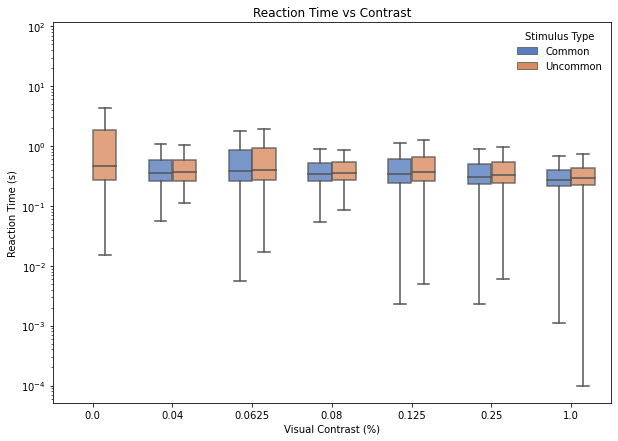

In [146]:
plot_reaction_time(all_biased_sessions)

In [143]:
def plot_accuracy(df: pd.DataFrame) -> None:
    """
    Groups data by contrast and stimulus type, calculates the proportion of 
    correct trials, and plots the resulting accuracy matrix against chance level.
    
    Parameters:
    df (pd.DataFrame): The preprocessed trials dataframe.
    """
    # Vectorized aggregation (C-speed calculation instead of Python lambda loop)
    accuracy_data = (
        df.assign(is_correct=(df["feedbackType"] == 1))
        .groupby(["contrast", "uncommon_stimulus"])["is_correct"]
        .mean()
        .reset_index(name="accuracy")
    )

    # Clean mapping of legend keys before plotting
    accuracy_data["Stimulus Type"] = accuracy_data["uncommon_stimulus"].map(
        {0: "Common", 1: "Uncommon", False: "Common", True: "Uncommon"}
    )

    # Object-Oriented figure layout control
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create the barplot
    sns.barplot(
        data=accuracy_data,
        x="contrast",
        y="accuracy",
        hue="Stimulus Type",
        palette="muted",
        ax=ax
    )

    # Add a baseline chance level line at 50% accuracy
    ax.axhline(
        0.5, color="black", linestyle="--", alpha=0.5, label="Chance Level (50%)"
    )

    # Formatting adjustments via the explicit axis object
    ax.set_title("Task Accuracy by Visual Contrast and Stimulus Type", fontsize=14, pad=12)
    ax.set_xlabel("Visual Contrast (%)", fontsize=12)
    ax.set_ylabel("Accuracy (Proportion Correct)", fontsize=12)
    ax.set_ylim(0, 1.05) 

    # Clean up the legend layout to elegantly bundle the bars and the chance line
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc="lower right", frameon=True, facecolor="white")

    plt.tight_layout()
    plt.show()

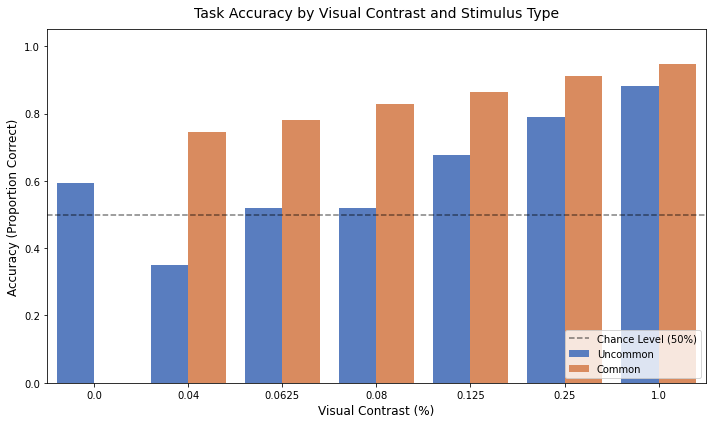

In [144]:
plot_accuracy(all_biased_sessions)

Once we have this large training table aggregated across all subjects we can manipulate this table to view different properties. For example we can see how the pyshcometric curves varies across the different training stages across all subjects

<Axes: xlabel='signed_contrast', ylabel='choice'>

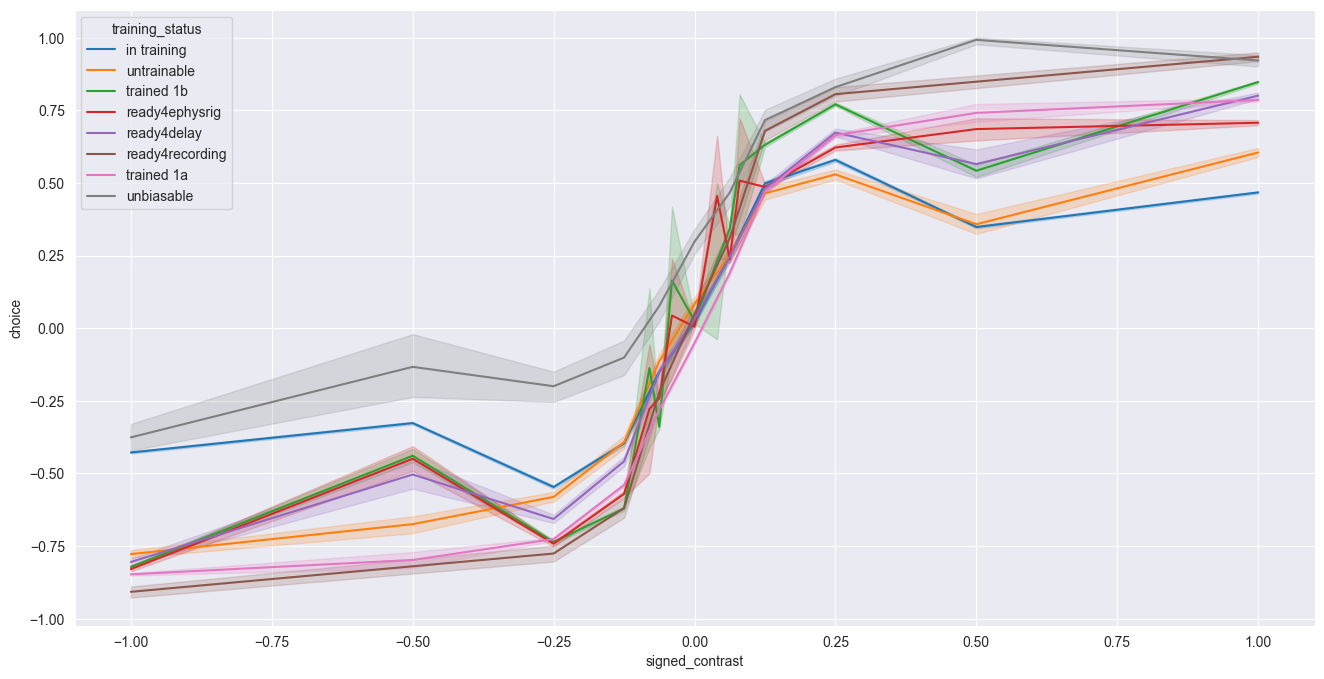

In [ ]:
import seaborn as sns
# plot psychometric curves for the whole dataframe
all_trials = all_trials.reset_index()
all_trials['signed_contrast'] = np.nan
i = np.isnan(all_trials['contrastRight'])
all_trials.loc[i , 'signed_contrast'] = all_trials.loc[i, 'contrastLeft']
all_trials.loc[~i, 'signed_contrast'] = - all_trials.loc[~i, 'contrastRight']

fig, ax = plt.subplots(1, 1, sharex=True, figsize=(16, 8))
sns.lineplot(data=all_trials.loc[all_trials['probabilityLeft'] == 0.5], x='signed_contrast', y='choice', hue='training_status', ax=ax)

Or we can look how the performance on easy trial progresses over training days across labs

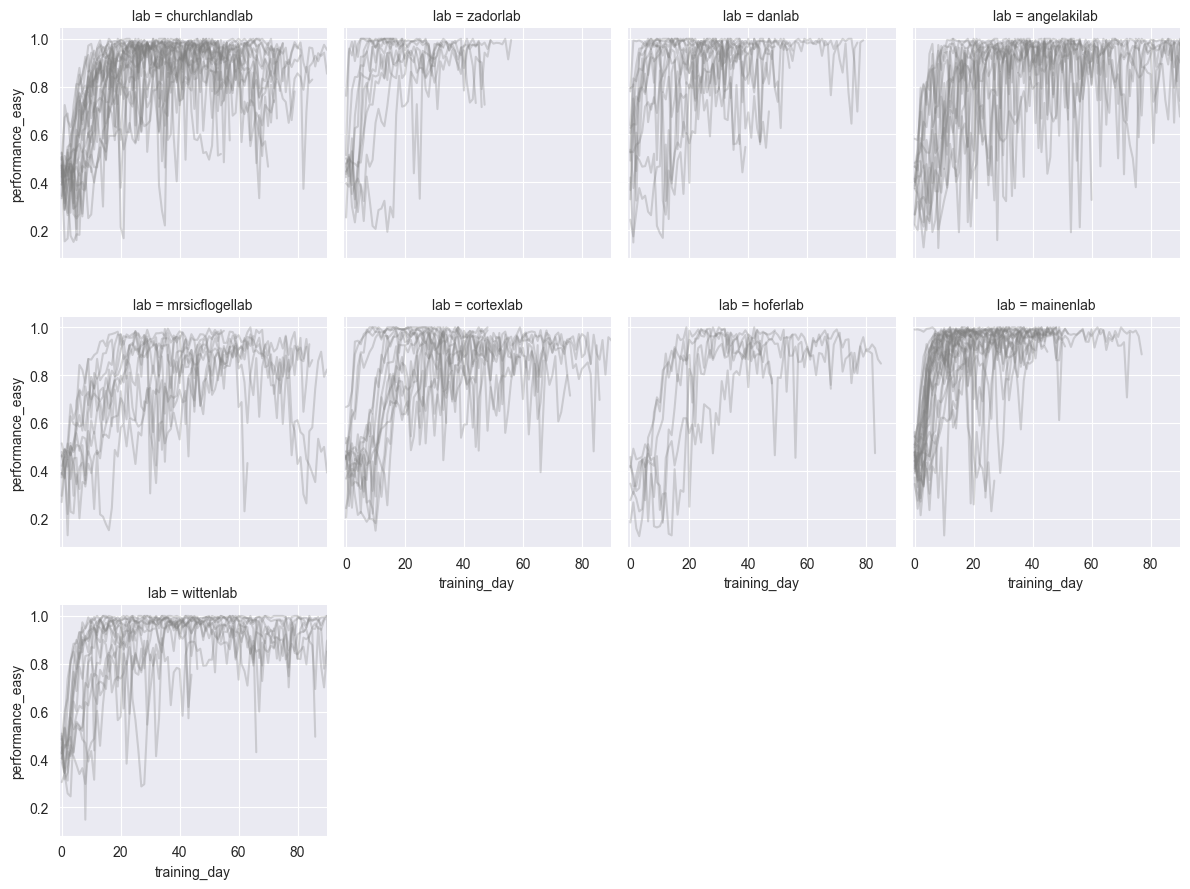

In [ ]:
# Remove duplicate rows that we don't need for the plots
fig = sns.FacetGrid(all_trials.drop_duplicates('session'),
                    col="lab", col_wrap=4,
                    sharex=True, sharey=True, aspect=1, hue="subject", xlim=[-1, 90])
fig.map(sns.lineplot, "training_day",
        "performance_easy", color='gray', alpha=0.3)

# Additional resources

Documentation

- [ONE documentation](https://int-brain-lab.github.io/iblenv/notebooks_external/one_quickstart.html#)
- [Getting started with ONE](https://colab.research.google.com/drive/1y3sRI1wC7qbWqN6skvulzPOp6xw8tLm7)
- [Loading trials data](https://int-brain-lab.github.io/iblenv/notebooks_external/loading_trials_data.html)


Where can I find help?
- Issues with the data? Post an issue here: https://neurostars.org/ with the tag `ibl`
- Alternatively post an issue here: https://github.com/int-brain-lab/iblenv/issues
- General questions about the datasets or publications? Email: info@internationalbrainlab.org




> *All data are made available under the CC BY 4.0 license.*